In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install timm torchmetrics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 21.3 MB/s eta 0:00:00


Imports + config + seed

In [2]:
import os, json, random, math
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import timm
from torchmetrics.classification import MulticlassAccuracy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---------------- CONFIG (edit if your paths differ) ----------------
DATA_DIR = "/content/drive/MyDrive/TASK01/data/"
TRAIN_CSV = os.path.join(DATA_DIR, "train_event_gap_reduced.csv")
DEV_CSV   = os.path.join(DATA_DIR, "dev_event_gap_reduced.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test_event_gap_reduced.csv")

IMAGE_ROOT = DATA_DIR  # same style you used: join(root, df["image"])

OUT_DIR = "/content/drive/MyDrive/TASK01/models/task01b_image_research_v2"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# Train teacher (pretrained strong model)
TEACHER_MODEL_NAME = "convnext_small"   # strong on small datasets
TEACHER_EPOCHS = 20
TEACHER_LR = 2e-4
TEACHER_WD = 0.05
TEACHER_PATIENCE = 5

# Train student (custom research model)
STUDENT_EPOCHS = 25
STUDENT_LR = 5e-4
STUDENT_WD = 0.02
STUDENT_PATIENCE = 6

# Distillation settings
USE_DISTILLATION = True
DISTILL_ALPHA = 0.6   # blend: (1-a)*CE + a*KD
DISTILL_T = 2.0

USE_AMP = True
CLIP_NORM = 1.0

LABEL_MAP = {"earthquake": 0, "floods": 1, "hurricane": 2, "wildfires": 3}
ID2LABEL = {v:k for k,v in LABEL_MAP.items()}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)
print("LABEL_MAP:", LABEL_MAP)

device: cuda
LABEL_MAP: {'earthquake': 0, 'floods': 1, 'hurricane': 2, 'wildfires': 3}


Load CSVs + label mapping + sanity checks

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
dev_df   = pd.read_csv(DEV_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train:", len(train_df), "Dev:", len(dev_df), "Test:", len(test_df))
print("Columns:", list(train_df.columns))

if "image" not in train_df.columns:
    raise ValueError("CSV must contain column 'image' with image relative path")
if "event_name" not in train_df.columns:
    raise ValueError("CSV must contain column 'event_name' with labels")

def add_label_id(df):
    df = df.copy()
    df["label_image_id"] = df["event_name"].map(LABEL_MAP)
    return df

train_df = add_label_id(train_df)
dev_df   = add_label_id(dev_df)
test_df  = add_label_id(test_df)

# unmapped labels?
for name, df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    bad = df["label_image_id"].isna().sum()
    if bad > 0:
        print(df[df["label_image_id"].isna()][["event_name"]].drop_duplicates().head(20))
        raise ValueError(f"{name}: found unmapped event_name values.")

print("✅ label mapping OK")

def resolve_path(p):
    if isinstance(p, str) and os.path.isabs(p):
        return p
    return os.path.join(IMAGE_ROOT, str(p))

def verify_and_filter(df, split):
    df = df.copy()
    df["image_fullpath"] = df["image"].apply(resolve_path)
    ok = df["image_fullpath"].apply(os.path.exists)
    missing = (~ok).sum()
    if missing:
        print(f"⚠️ {split}: missing {missing}/{len(df)} images. Dropping them.")
        df = df[ok].copy()
    return df.reset_index(drop=True)

train_df = verify_and_filter(train_df, "TRAIN")
dev_df   = verify_and_filter(dev_df, "DEV")
test_df  = verify_and_filter(test_df, "TEST")

print("After filtering -> Train:", len(train_df), "Dev:", len(dev_df), "Test:", len(test_df))

def print_dist(df, name):
    counts = df["label_image_id"].value_counts().sort_index()
    total = len(df)
    print(f"\n{name} distribution (n={total}):")
    for i in range(4):
        c = int(counts.get(i, 0))
        print(f"  {i} ({ID2LABEL[i]}): {c} ({c/total:.2%})")

print_dist(train_df, "TRAIN")
print_dist(dev_df, "DEV")
print_dist(test_df, "TEST")

Train: 940 Dev: 217 Test: 146
Columns: ['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label']
✅ label mapping OK
After filtering -> Train: 940 Dev: 217 Test: 146

TRAIN distribution (n=940):
  0 (earthquake): 239 (25.43%)
  1 (floods): 181 (19.26%)
  2 (hurricane): 285 (30.32%)
  3 (wildfires): 235 (25.00%)

DEV distribution (n=217):
  0 (earthquake): 60 (27.65%)
  1 (floods): 41 (18.89%)
  2 (hurricane): 60 (27.65%)
  3 (wildfires): 56 (25.81%)

TEST distribution (n=146):
  0 (earthquake): 35 (23.97%)
  1 (floods): 28 (19.18%)
  2 (hurricane): 45 (30.82%)
  3 (wildfires): 38 (26.03%)


Quick raw sample visualization (sanity)

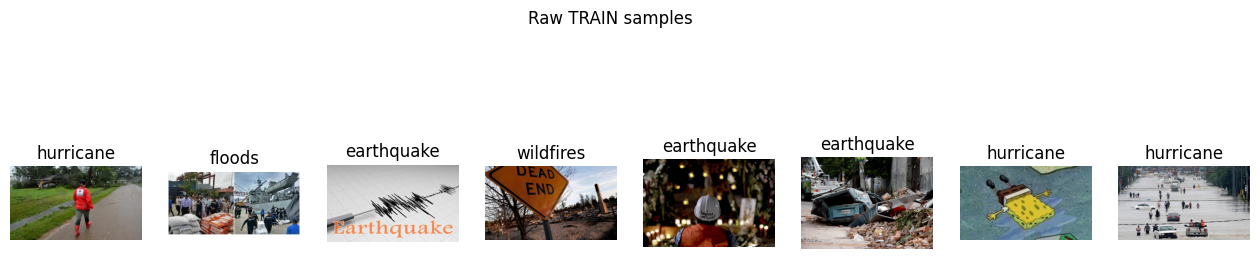

In [4]:
def show_grid(df, title, n=8):
    n = min(n, len(df))
    idxs = np.random.choice(len(df), size=n, replace=False)
    plt.figure(figsize=(16, 4))
    for i, idx in enumerate(idxs):
        p = df.loc[idx, "image_fullpath"]
        y = int(df.loc[idx, "label_image_id"])
        img = Image.open(p).convert("RGB")
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(ID2LABEL[y])
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_grid(train_df, "Raw TRAIN samples", n=8)

Preprocessing (tuned to preserve context)

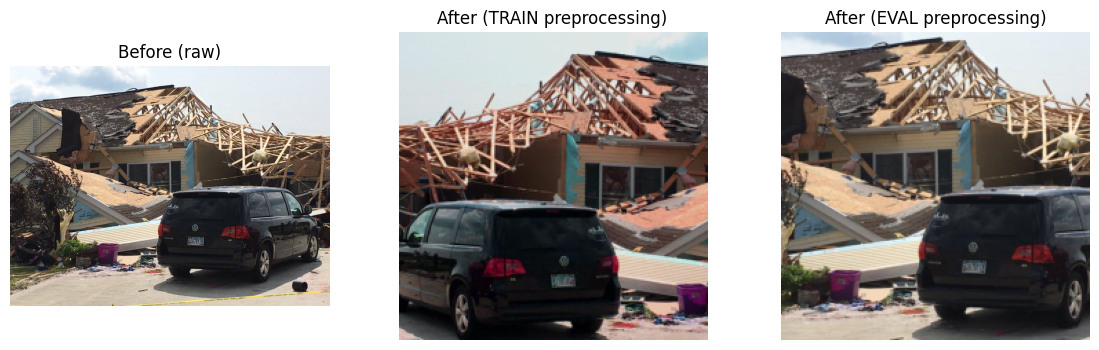

In [5]:
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def unnormalize(img_t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    x = img_t.cpu() * std + mean
    x = x.permute(1,2,0).numpy()
    return np.clip(x, 0, 1)

def show_before_after(df, idx=0):
    p = df.loc[idx, "image_fullpath"]
    raw = Image.open(p).convert("RGB")
    after_train = train_tf(raw)
    after_eval  = eval_tf(raw)

    plt.figure(figsize=(14,4))
    plt.subplot(1,3,1); plt.title("Before (raw)"); plt.imshow(raw); plt.axis("off")
    plt.subplot(1,3,2); plt.title("After (TRAIN preprocessing)"); plt.imshow(unnormalize(after_train)); plt.axis("off")
    plt.subplot(1,3,3); plt.title("After (EVAL preprocessing)"); plt.imshow(unnormalize(after_eval)); plt.axis("off")
    plt.show()

show_before_after(train_df, idx=0)

Dataset + DataLoaders + loader sanity checks

In [6]:
class DisasterImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        p = self.df.loc[idx, "image_fullpath"]
        y = int(self.df.loc[idx, "label_image_id"])
        img = Image.open(p).convert("RGB")
        img = self.transform(img)
        return img, y

train_ds = DisasterImageDataset(train_df, train_tf)
dev_ds   = DisasterImageDataset(dev_df, eval_tf)
test_ds  = DisasterImageDataset(test_df, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
dev_loader   = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

xb, yb = next(iter(train_loader))
print("batch x:", xb.shape, xb.dtype, "batch y:", yb.shape, yb.dtype)
print("y sample:", yb[:10].tolist())
assert xb.shape[2] == IMG_SIZE and xb.shape[3] == IMG_SIZE
assert yb.min() >= 0 and yb.max() <= 3
print("✅ DataLoaders OK")

batch x: torch.Size([32, 3, 224, 224]) torch.float32 batch y: torch.Size([32]) torch.int64
y sample: [0, 2, 2, 2, 1, 2, 0, 0, 3, 3]
✅ DataLoaders OK


Metrics helpers (train/eval) + plots

In [7]:
from torch.amp import autocast, GradScaler

def plot_curves(history, title_prefix=""):
    plt.figure(figsize=(6,4))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["dev_loss"], label="dev_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["dev_acc"], label="dev_acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

@torch.no_grad()
def eval_probs(model, loader):
    model.eval()
    all_probs = []
    all_y = []
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        total_loss += loss.item()
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.detach().cpu())
        all_y.append(yb.detach().cpu())
    all_probs = torch.cat(all_probs).numpy()
    all_y = torch.cat(all_y).numpy()
    return total_loss / max(1, len(loader)), all_probs, all_y

@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return total_loss / max(1, len(loader)), correct / max(1, total)

Train Teacher (Pretrained Strong Model)

Build teacher


In [8]:
teacher = timm.create_model(TEACHER_MODEL_NAME, pretrained=True, num_classes=4).to(device)
print("Teacher:", TEACHER_MODEL_NAME)

teacher_best_path = os.path.join(OUT_DIR, "best_teacher.pt")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

Teacher: convnext_small


Train teacher

[Teacher] Epoch 01 | train loss 1.5469 acc 0.3064 || dev loss 1.4738 acc 0.2581
  ✅ best teacher updated
[Teacher] Epoch 02 | train loss 1.3645 acc 0.3564 || dev loss 1.3021 acc 0.3687
  ✅ best teacher updated
[Teacher] Epoch 03 | train loss 1.3119 acc 0.3713 || dev loss 1.1991 acc 0.4101
  ✅ best teacher updated
[Teacher] Epoch 04 | train loss 1.2629 acc 0.3926 || dev loss 1.1769 acc 0.4654
  ✅ best teacher updated
[Teacher] Epoch 05 | train loss 1.2386 acc 0.4468 || dev loss 1.1656 acc 0.4378
  ✅ best teacher updated
[Teacher] Epoch 06 | train loss 1.1844 acc 0.4702 || dev loss 1.1672 acc 0.4885
[Teacher] Epoch 07 | train loss 1.1290 acc 0.5074 || dev loss 1.0630 acc 0.5207
  ✅ best teacher updated
[Teacher] Epoch 08 | train loss 1.0733 acc 0.5309 || dev loss 1.0796 acc 0.5346
[Teacher] Epoch 09 | train loss 1.0602 acc 0.5351 || dev loss 1.0234 acc 0.5714
  ✅ best teacher updated
[Teacher] Epoch 10 | train loss 0.9619 acc 0.5957 || dev loss 0.9607 acc 0.5899
  ✅ best teacher updated


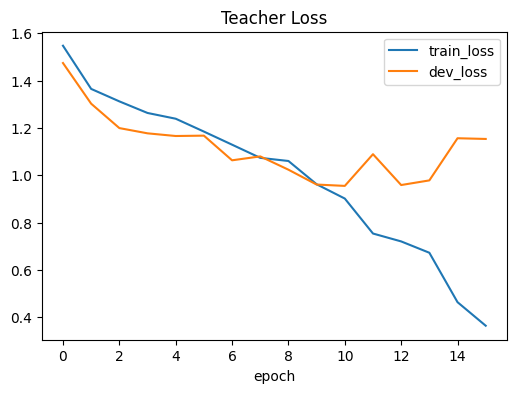

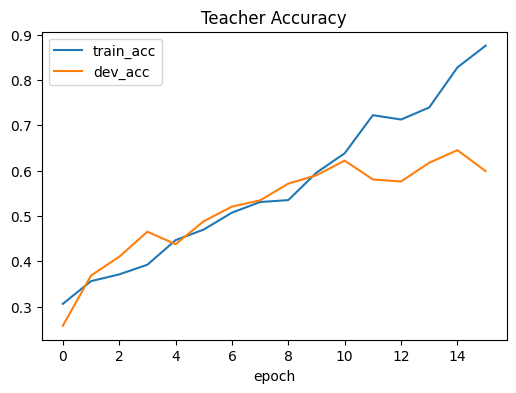

✅ Loaded best teacher: /content/drive/MyDrive/TASK01/models/task01b_image_research_v2/best_teacher.pt


In [9]:
teacher_opt = torch.optim.AdamW(teacher.parameters(), lr=TEACHER_LR, weight_decay=TEACHER_WD)

# cosine schedule (simple)
teacher_sched = torch.optim.lr_scheduler.CosineAnnealingLR(teacher_opt, T_max=TEACHER_EPOCHS)

scaler = GradScaler(enabled=(USE_AMP and device.type == "cuda"))

history_teacher = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}
best_dev = float("inf")
pat = 0

for epoch in range(1, TEACHER_EPOCHS + 1):
    teacher.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        teacher_opt.zero_grad(set_to_none=True)

        with autocast(device_type="cuda" if device.type=="cuda" else "cpu", enabled=(USE_AMP and device.type=="cuda")):
            logits = teacher(xb)
            loss = F.cross_entropy(logits, yb)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(teacher.parameters(), CLIP_NORM)
        scaler.step(teacher_opt)
        scaler.update()

        running_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    teacher_sched.step()

    train_loss = running_loss / max(1, total)
    train_acc = correct / max(1, total)
    dev_loss, dev_acc = eval_acc(teacher, dev_loader)

    history_teacher["train_loss"].append(train_loss)
    history_teacher["train_acc"].append(train_acc)
    history_teacher["dev_loss"].append(dev_loss)
    history_teacher["dev_acc"].append(dev_acc)

    print(f"[Teacher] Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} || dev loss {dev_loss:.4f} acc {dev_acc:.4f}")

    if dev_loss < best_dev:
        best_dev = dev_loss
        pat = 0
        torch.save(teacher.state_dict(), teacher_best_path)
        print("  ✅ best teacher updated")
    else:
        pat += 1
        if pat >= TEACHER_PATIENCE:
            print("  🛑 teacher early stopping")
            break

teacher.load_state_dict(torch.load(teacher_best_path, map_location=device))
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

plot_curves(history_teacher, title_prefix="Teacher")
print("✅ Loaded best teacher:", teacher_best_path)

Train Student (Custom Model + Proper Distillation)

Custom student model (clear layers)

In [10]:
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, act=nn.SiLU):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = act()
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class SEBlock(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        self.fc1 = nn.Conv2d(ch, ch // r, 1)
        self.fc2 = nn.Conv2d(ch // r, ch, 1)
    def forward(self, x):
        s = F.adaptive_avg_pool2d(x, 1)
        s = F.silu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        return x * s

class ResidualBlock(nn.Module):
    def __init__(self, ch, drop=0.1):
        super().__init__()
        self.c1 = ConvBNAct(ch, ch, 3, 1, 1)
        self.c2 = nn.Conv2d(ch, ch, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(ch)
        self.se = SEBlock(ch)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        h = self.c1(x)
        h = self.bn2(self.c2(h))
        h = self.se(h)
        h = self.drop(h)
        return F.silu(x + h)

class MHSA2D(nn.Module):
    def __init__(self, dim, heads=4, attn_drop=0.1, proj_drop=0.1):
        super().__init__()
        self.heads = heads
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.scale = (dim // heads) ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        t = x.flatten(2).transpose(1, 2)  # [B, HW, C]
        qkv = self.qkv(t).reshape(B, -1, 3, self.heads, C // self.heads).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        out = (attn @ v).transpose(1,2).reshape(B, -1, C)
        out = self.proj_drop(self.proj(out))
        out = out.transpose(1,2).reshape(B, C, H, W)
        return out

class HybridDisasterNet(nn.Module):
    def __init__(self, num_classes=4, width=64, drop=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNAct(3, width, 3, 2, 1),      # 224 -> 112
            ConvBNAct(width, width, 3, 1, 1),
        )
        self.stage1 = nn.Sequential(
            ConvBNAct(width, width*2, 3, 2, 1), # 112 -> 56
            ResidualBlock(width*2, drop=drop),
            ResidualBlock(width*2, drop=drop),
        )
        self.stage2 = nn.Sequential(
            ConvBNAct(width*2, width*4, 3, 2, 1), # 56 -> 28
            ResidualBlock(width*4, drop=drop),
            ResidualBlock(width*4, drop=drop),
        )
        self.stage3 = nn.Sequential(
            ConvBNAct(width*4, width*6, 3, 2, 1), # 28 -> 14
            ResidualBlock(width*6, drop=drop),
        )

        dim = width*6
        self.mhsa1 = MHSA2D(dim=dim, heads=6)
        self.mhsa2 = MHSA2D(dim=dim, heads=6)

        self.norm = nn.BatchNorm2d(dim)
        self.dropout = nn.Dropout(drop)
        self.fc = nn.Linear(dim, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        x = x + self.mhsa1(x)
        x = x + self.mhsa2(x)

        x = F.silu(self.norm(x))
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

student = HybridDisasterNet(num_classes=4, width=64, drop=0.2).to(device)
print(student)

student_best_path = os.path.join(OUT_DIR, "best_student.pt")

HybridDisasterNet(
  (stem): Sequential(
    (0): ConvBNAct(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU()
    )
    (1): ConvBNAct(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU()
    )
  )
  (stage1): Sequential(
    (0): ConvBNAct(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU()
    )
    (1): ResidualBlock(
      (c1): ConvBNAct(
        (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

Distillation loss + train student

[Student] Epoch 01 | train loss 0.9195 acc 0.3702 || dev loss 1.2703 acc 0.4470
  ✅ best student updated
[Student] Epoch 02 | train loss 0.8388 acc 0.4287 || dev loss 1.1883 acc 0.4977
  ✅ best student updated
[Student] Epoch 03 | train loss 0.7959 acc 0.4309 || dev loss 1.1242 acc 0.4793
  ✅ best student updated
[Student] Epoch 04 | train loss 0.7557 acc 0.4574 || dev loss 1.1147 acc 0.5069
  ✅ best student updated
[Student] Epoch 05 | train loss 0.7258 acc 0.4638 || dev loss 1.1120 acc 0.5115
  ✅ best student updated
[Student] Epoch 06 | train loss 0.7116 acc 0.4862 || dev loss 1.1460 acc 0.4931
[Student] Epoch 07 | train loss 0.6781 acc 0.5043 || dev loss 1.2663 acc 0.4977
[Student] Epoch 08 | train loss 0.6550 acc 0.5202 || dev loss 1.0407 acc 0.5714
  ✅ best student updated
[Student] Epoch 09 | train loss 0.6374 acc 0.5011 || dev loss 1.0468 acc 0.5714
[Student] Epoch 10 | train loss 0.5848 acc 0.5489 || dev loss 1.1287 acc 0.5207
[Student] Epoch 11 | train loss 0.6255 acc 0.5298 

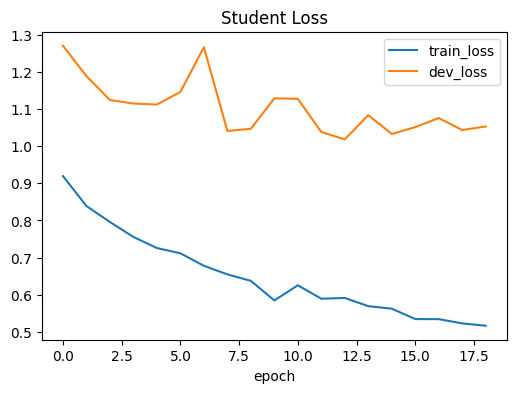

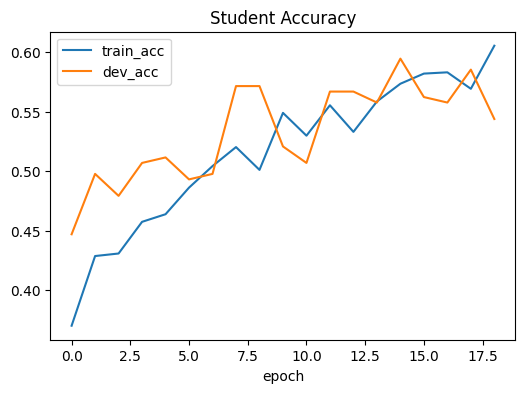

✅ Loaded best student: /content/drive/MyDrive/TASK01/models/task01b_image_research_v2/best_student.pt


In [11]:
def kd_loss(student_logits, teacher_logits, T=2.0):
    p_s = F.log_softmax(student_logits / T, dim=1)
    p_t = F.softmax(teacher_logits / T, dim=1)
    return F.kl_div(p_s, p_t, reduction="batchmean") * (T * T)

student_opt = torch.optim.AdamW(student.parameters(), lr=STUDENT_LR, weight_decay=STUDENT_WD)
student_sched = torch.optim.lr_scheduler.CosineAnnealingLR(student_opt, T_max=STUDENT_EPOCHS)

scaler = GradScaler(enabled=(USE_AMP and device.type == "cuda"))

history_student = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}
best_dev = float("inf")
pat = 0

for epoch in range(1, STUDENT_EPOCHS + 1):
    student.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        student_opt.zero_grad(set_to_none=True)

        with autocast(device_type="cuda" if device.type=="cuda" else "cpu", enabled=(USE_AMP and device.type=="cuda")):
            s_logits = student(xb)
            loss_ce = F.cross_entropy(s_logits, yb)

            if USE_DISTILLATION:
                with torch.no_grad():
                    t_logits = teacher(xb)
                loss_kd = kd_loss(s_logits, t_logits, T=DISTILL_T)
                loss = (1 - DISTILL_ALPHA) * loss_ce + DISTILL_ALPHA * loss_kd
            else:
                loss = loss_ce

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), CLIP_NORM)
        scaler.step(student_opt)
        scaler.update()

        running_loss += loss.item() * xb.size(0)
        pred = s_logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    student_sched.step()

    train_loss = running_loss / max(1, total)
    train_acc = correct / max(1, total)
    dev_loss, dev_acc = eval_acc(student, dev_loader)

    history_student["train_loss"].append(train_loss)
    history_student["train_acc"].append(train_acc)
    history_student["dev_loss"].append(dev_loss)
    history_student["dev_acc"].append(dev_acc)

    print(f"[Student] Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} || dev loss {dev_loss:.4f} acc {dev_acc:.4f}")

    if dev_loss < best_dev:
        best_dev = dev_loss
        pat = 0
        torch.save(student.state_dict(), student_best_path)
        print("  ✅ best student updated")
    else:
        pat += 1
        if pat >= STUDENT_PATIENCE:
            print("  🛑 student early stopping")
            break

student.load_state_dict(torch.load(student_best_path, map_location=device))
student.eval()

plot_curves(history_student, title_prefix="Student")
print("✅ Loaded best student:", student_best_path)

Evaluate teacher + student on test + confusion matrices


Teacher (convnext_small) TEST loss: 0.9099  TEST acc: 0.6712

              precision    recall  f1-score   support

  earthquake     0.5682    0.7143    0.6329        35
      floods     0.8000    0.4286    0.5581        28
   hurricane     0.6809    0.7111    0.6957        45
   wildfires     0.7250    0.7632    0.7436        38

    accuracy                         0.6712       146
   macro avg     0.6935    0.6543    0.6576       146
weighted avg     0.6882    0.6712    0.6667       146

Confusion matrix (rows=true, cols=pred):
 [[25  1  5  4]
 [ 6 12  6  4]
 [ 8  2 32  3]
 [ 5  0  4 29]]


<Figure size 600x600 with 0 Axes>

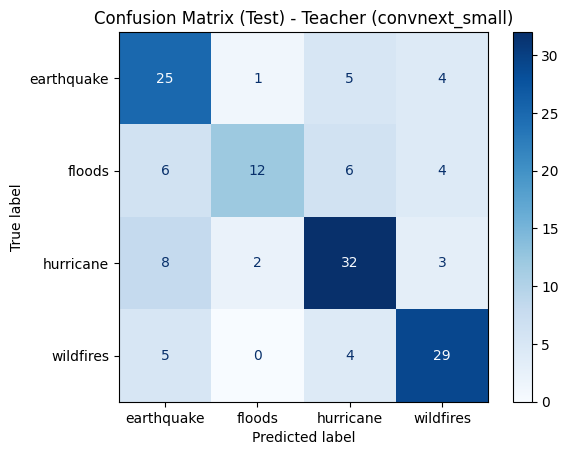


Student (HybridDisasterNet) TEST loss: 1.0994  TEST acc: 0.5822

              precision    recall  f1-score   support

  earthquake     0.5263    0.5714    0.5479        35
      floods     0.8889    0.2857    0.4324        28
   hurricane     0.5238    0.7333    0.6111        45
   wildfires     0.6667    0.6316    0.6486        38

    accuracy                         0.5822       146
   macro avg     0.6514    0.5555    0.5600       146
weighted avg     0.6316    0.5822    0.5715       146

Confusion matrix (rows=true, cols=pred):
 [[20  0  9  6]
 [ 5  8 12  3]
 [ 8  1 33  3]
 [ 5  0  9 24]]


<Figure size 600x600 with 0 Axes>

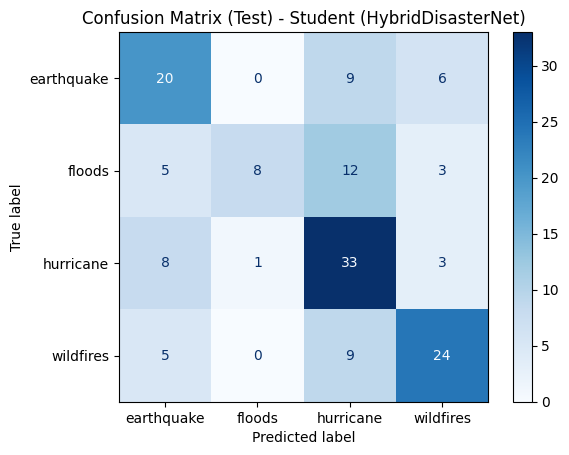

In [12]:
def evaluate_full(model, loader, title="Model"):
    test_loss, probs, y_true = eval_probs(model, loader)
    y_pred = probs.argmax(axis=1)
    acc = (y_pred == y_true).mean()

    print(f"\n{title} TEST loss: {test_loss:.4f}  TEST acc: {acc:.4f}\n")

    target_names = [ID2LABEL[i] for i in range(4)]
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3])
    print("Confusion matrix (rows=true, cols=pred):\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    plt.figure(figsize=(6,6))
    disp.plot(values_format="d", cmap="Blues")
    plt.title(f"Confusion Matrix (Test) - {title}")
    plt.grid(False)
    plt.show()

    return acc, cm

teacher_acc, teacher_cm = evaluate_full(teacher, test_loader, title=f"Teacher ({TEACHER_MODEL_NAME})")
student_acc, student_cm = evaluate_full(student, test_loader, title="Student (HybridDisasterNet)")

Save model package for integration (student + label map + config)

In [13]:
# Save student weights
torch.save(student.state_dict(), os.path.join(OUT_DIR, "student_weights.pt"))

# Save teacher weights too (optional for later)
torch.save(teacher.state_dict(), os.path.join(OUT_DIR, "teacher_weights.pt"))

pkg = {
    "task": "Task-01B Image (4-class disaster)",
    "label_map": LABEL_MAP,
    "id2label": ID2LABEL,
    "img_size": IMG_SIZE,
    "teacher_model": TEACHER_MODEL_NAME,
    "student_model": "HybridDisasterNet(width=64)",
    "train_preprocessing": "Resize256 + RandomCrop224 + HFlip + ColorJitter + Normalize",
    "eval_preprocessing": "Resize256 + CenterCrop224 + Normalize",
    "distillation_used": USE_DISTILLATION,
    "distill_alpha": DISTILL_ALPHA,
    "distill_T": DISTILL_T
}

with open(os.path.join(OUT_DIR, "model_package.json"), "w") as f:
    json.dump(pkg, f, indent=2)

print("✅ Saved package to:", OUT_DIR)

✅ Saved package to: /content/drive/MyDrive/TASK01/models/task01b_image_research_v2


Load saved student + single-image prediction sanity

In [14]:
def load_student(model_dir):
    with open(os.path.join(model_dir, "model_package.json"), "r") as f:
        pkg = json.load(f)

    model = HybridDisasterNet(num_classes=4, width=64, drop=0.2).to(device)
    model.load_state_dict(torch.load(os.path.join(model_dir, "student_weights.pt"), map_location=device))
    model.eval()
    id2label = pkg["id2label"]
    id2label = {int(k): v for k, v in id2label.items()}  # ensure int keys
    return model, id2label

@torch.no_grad()
def predict_one(image_path, model):
    img = Image.open(image_path).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(device)
    logits = model(x)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    pred = int(probs.argmax())
    return pred, probs

loaded_model, loaded_id2label = load_student(OUT_DIR)

sample_path = test_df.loc[0, "image_fullpath"]
pred_id, probs = predict_one(sample_path, loaded_model)

print("Image:", sample_path)
print("Pred:", pred_id, loaded_id2label[pred_id])
print("Probs:")
for i, p in enumerate(probs):
    print(f"  {i} {loaded_id2label[i]}: {p:.4f}")

Image: /content/drive/MyDrive/TASK01/data/data_image/california_wildfires/23_10_2017/922417012801929216_0.jpg
Pred: 3 wildfires
Probs:
  0 earthquake: 0.0188
  1 floods: 0.0169
  2 hurricane: 0.0269
  3 wildfires: 0.9374


**TEST**

In [16]:
import torch
import torch.nn.functional as F
import json
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_DIR = "/content/drive/MyDrive/TASK01/models/task01b_image_research_v2"

IMG_SIZE = 224

# ----- define eval preprocessing (must match training) -----
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225]),
])

def unnormalize(img_t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    x = img_t.cpu() * std + mean
    x = x.permute(1,2,0).numpy()
    return x.clip(0,1)

In [17]:
import torch
import torch.nn.functional as F
import json
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_DIR = "/content/drive/MyDrive/TASK01/models/task01b_image_research_v2"

IMG_SIZE = 224

# ----- define eval preprocessing (must match training) -----
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225]),
])

def unnormalize(img_t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    x = img_t.cpu() * std + mean
    x = x.permute(1,2,0).numpy()
    return x.clip(0,1)

In [18]:
# Load label map
with open(f"{MODEL_DIR}/model_package.json", "r") as f:
    pkg = json.load(f)

ID2LABEL = {int(k): v for k,v in pkg["id2label"].items()}

# Load model
model = HybridDisasterNet(num_classes=4, width=64).to(device)
model.load_state_dict(torch.load(f"{MODEL_DIR}/student_weights.pt", map_location=device))
model.eval()

print("✅ Model loaded")
print("Labels:", ID2LABEL)

✅ Model loaded
Labels: {0: 'earthquake', 1: 'floods', 2: 'hurricane', 3: 'wildfires'}


In [19]:
@torch.no_grad()
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(device)

    logits = model(x)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    pred_id = int(probs.argmax())

    # Display image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Prediction: {ID2LABEL[pred_id]}")
    plt.axis("off")
    plt.show()

    print("Prediction:", pred_id, "-", ID2LABEL[pred_id])
    print("Probabilities:")
    for i, p in enumerate(probs):
        print(f"  {i} {ID2LABEL[i]}: {p:.4f}")

    return pred_id, probs

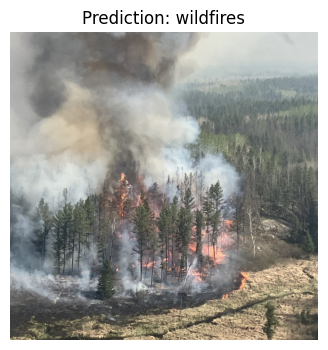

Prediction: 3 - wildfires
Probabilities:
  0 earthquake: 0.0947
  1 floods: 0.1033
  2 hurricane: 0.3116
  3 wildfires: 0.4904


(3, array([0.09469692, 0.10329783, 0.3116201 , 0.49038512], dtype=float32))

In [23]:
image_path = "/content/drive/MyDrive/TASK01/data/sample_image_1.jpg"
predict_image(image_path)